# Student Performance Prediction

Trying to predict if a student passes or fails based on stuff like study hours,
attendance, previous marks etc. Using the UCI student performance dataset (real data,
395 students from 2 Portuguese schools) but renamed the columns to match my synopsis.

Mapping I used (UCI col -> my col name):
- studytime -> Study_Hours
- absences -> Attendance (inverted it, less absences = higher attendance)
- G1 -> Previous_Marks
- G2 -> Internal_Marks
- avg(G1,G2) -> Assignments (UCI doesn't have an assignments column so I approximated this)
- Medu+Fedu -> Socio_Economic_Status
- G3 -> Final_Percentage / Final_Result (pass if G3>=10 out of 20)


## Step 1: Import Libraries

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


 # Data Collection


In [42]:
df = pd.read_csv("student_data_real.csv")
print("Shape:", df.shape)
df.head()

Shape: (395, 9)


,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks,Socio_Economic_Status,Final_Percentage,Final_Result
0,S1000,2,92.0,25.0,30.0,30.0,3,30.0,Fail
1,S1001,2,94.7,25.0,24.3,25.0,1,30.0,Fail
2,S1002,2,86.7,35.0,40.7,40.0,1,50.0,Pass
3,S1003,3,97.3,75.0,80.1,70.0,3,75.0,Pass
4,S1004,2,94.7,30.0,38.8,50.0,3,50.0,Pass


## Data Exploration

In [43]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             395 non-null    object 
 1   Study_Hours            395 non-null    int64  
 2   Attendance             395 non-null    float64
 3   Previous_Marks         395 non-null    float64
 4   Assignments            395 non-null    float64
 5   Internal_Marks         395 non-null    float64
 6   Socio_Economic_Status  395 non-null    int64  
 7   Final_Percentage       395 non-null    float64
 8   Final_Result           395 non-null    object 
dtypes: float64(5), int64(2), object(2)
memory usage: 27.9+ KB


In [44]:
df.describe()


,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks,Socio_Economic_Status,Final_Percentage
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,2.035443,92.386582,54.544304,54.148354,53.569620,2.273418,52.075949
std,0.839240,10.669771,16.595973,17.688377,18.807523,0.790924,22.907213
min,1.000000,0.000000,15.000000,8.400000,0.000000,1.000000,0.000000
25%,1.000000,89.300000,40.000000,42.000000,45.000000,2.000000,40.000000
50%,2.000000,94.700000,55.000000,53.000000,55.000000,2.000000,55.000000
75%,2.000000,100.000000,65.000000,67.300000,65.000000,3.000000,70.000000
max,4.000000,100.000000,95.000000,100.000000,95.000000,3.000000,100.000000


In [45]:

df.isnull().sum()


,0
Student_ID,0
Study_Hours,0
Attendance,0
Previous_Marks,0
Assignments,0
Internal_Marks,0
Socio_Economic_Status,0
Final_Percentage,0
Final_Result,0


##  Data Preprocessing



In [46]:

for col in ["Attendance", "Assignments"]:
    df[col] = df[col].fillna(df[col].median())


print(df.isnull().sum().sum(), "missing values remaining")


le = LabelEncoder()
df["Final_Result_Encoded"] = le.fit_transform(df["Final_Result"])  # Fail=0, Pass=1
print(dict(zip(le.classes_, le.transform(le.classes_))))


0 missing values remaining
{'Fail': np.int64(0), 'Pass': np.int64(1)}


##  Exploratory Data Analysis


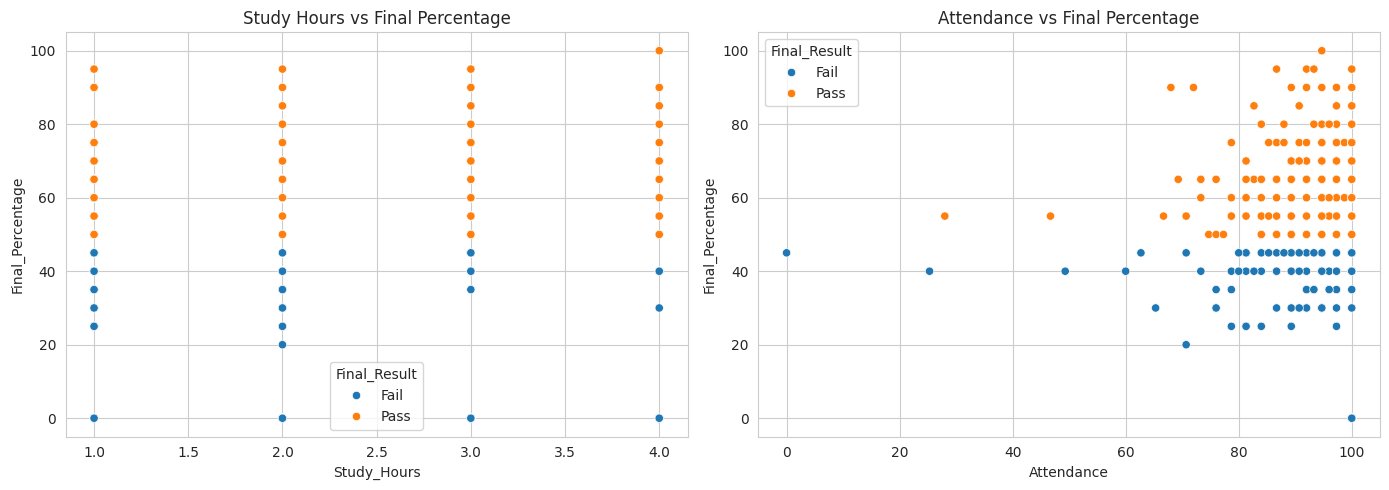

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="Study_Hours", y="Final_Percentage", hue="Final_Result", ax=axes[0])
axes[0].set_title("Study Hours vs Final Percentage")

sns.scatterplot(data=df, x="Attendance", y="Final_Percentage", hue="Final_Result", ax=axes[1])
axes[1].set_title("Attendance vs Final Percentage")
plt.tight_layout()
plt.savefig("eda_scatter.png", dpi=120)
plt.show()


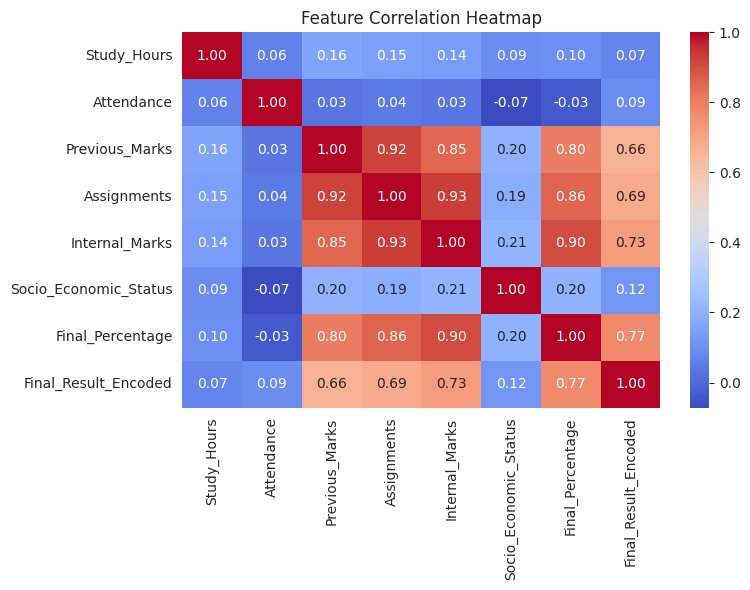

In [48]:

plt.figure(figsize=(8, 6))
numeric_cols = ["Study_Hours", "Attendance", "Previous_Marks", "Assignments",
                 "Internal_Marks", "Socio_Economic_Status", "Final_Percentage", "Final_Result_Encoded"]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120)
plt.show()


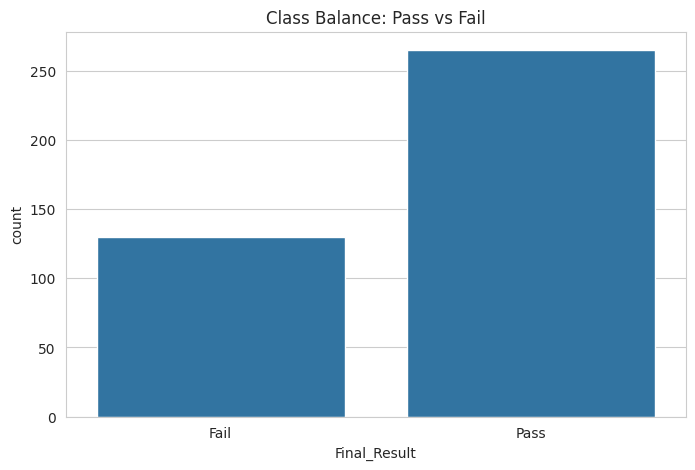

In [49]:
sns.countplot(data=df, x="Final_Result")
plt.title("Class Balance: Pass vs Fail")
plt.savefig("class_balance.png", dpi=120)
plt.show()


##  Feature Selection


In [50]:
features = ["Study_Hours", "Attendance", "Previous_Marks", "Assignments",
            "Internal_Marks", "Socio_Economic_Status"]

X = df[features]
y = df["Final_Result_Encoded"]

X.head()


,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks,Socio_Economic_Status
0,2,92.0,25.0,30.0,30.0,3
1,2,94.7,25.0,24.3,25.0,1
2,2,86.7,35.0,40.7,40.0,1
3,3,97.3,75.0,80.1,70.0,3
4,2,94.7,30.0,38.8,50.0,3


##  Train-Test Split & Feature Scaling


In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (316, 6)  Test size: (79, 6)


## Train Multiple Models


In [52]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True)
}

results = []

for name, model in models.items():
    if name in ["Logistic Regression", "Naive Bayes", "SVM"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1-Score": f1_score(y_test, preds, zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
results_df


,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.886076,0.940000,0.886792,0.912621
4,SVM,0.860759,0.956522,0.830189,0.888889
0,Logistic Regression,0.848101,0.918367,0.849057,0.882353
1,Decision Tree,0.848101,0.918367,0.849057,0.882353
3,Naive Bayes,0.797468,0.930233,0.754717,0.833333


##  Compare Models Visually

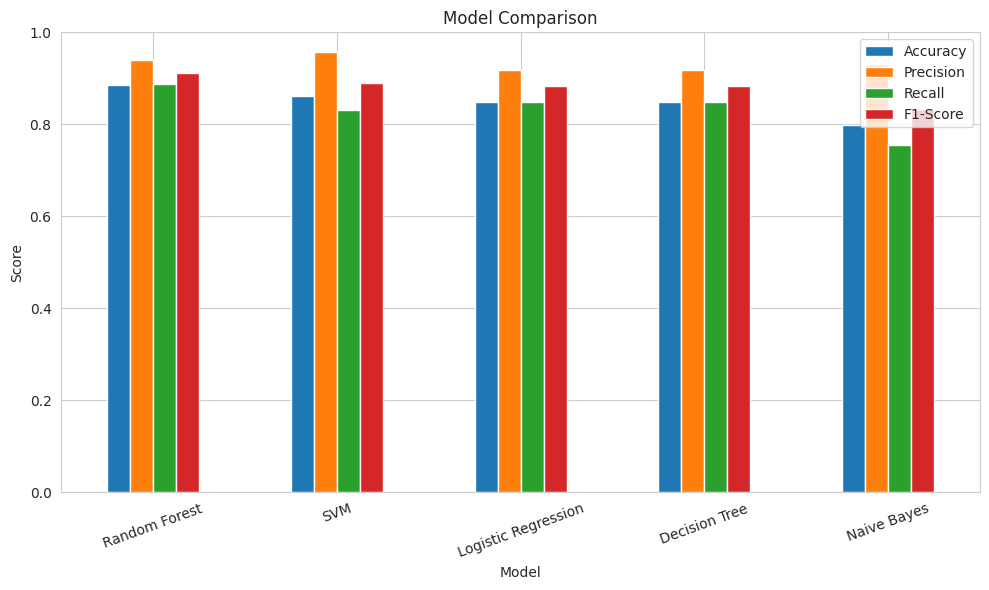

In [53]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar", figsize=(10, 6)
)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()


##  Confusion Matrix (Best Model)


Best model: Random Forest


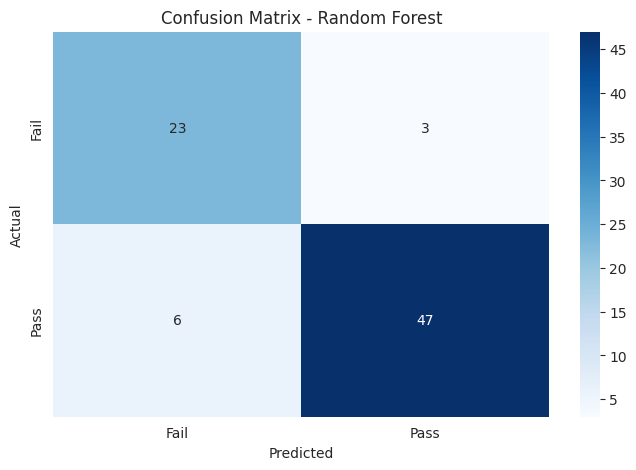

              precision    recall  f1-score   support

        Fail       0.79      0.88      0.84        26
        Pass       0.94      0.89      0.91        53

    accuracy                           0.89        79
   macro avg       0.87      0.89      0.87        79
weighted avg       0.89      0.89      0.89        79



In [54]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)

best_model = models[best_model_name]
if best_model_name in ["Logistic Regression", "Naive Bayes", "SVM"]:
    final_preds = best_model.predict(X_test_scaled)
else:
    final_preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, final_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fail", "Pass"], yticklabels=["Fail", "Pass"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()

print(classification_report(y_test, final_preds, target_names=["Fail", "Pass"]))


##Feature Importance


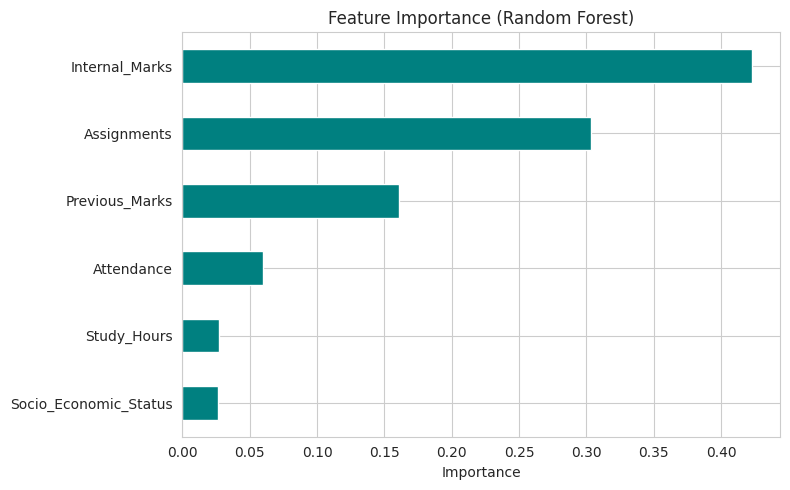

,0
Internal_Marks,0.422656
Assignments,0.303165
Previous_Marks,0.160916
Attendance,0.059747
Study_Hours,0.026907
Socio_Economic_Status,0.026608


In [55]:
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

importances.plot(kind="barh", figsize=(8, 5), color="teal")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120)
plt.show()

importances


## Predict for a New Student


In [56]:
def predict_student(study_hours, attendance, previous_marks, assignments,
                     internal_marks, socio_economic_status, model_name="Random Forest"):
    input_df = pd.DataFrame([{
        "Study_Hours": study_hours,
        "Attendance": attendance,
        "Previous_Marks": previous_marks,
        "Assignments": assignments,
        "Internal_Marks": internal_marks,
        "Socio_Economic_Status": socio_economic_status
    }])

    model = models[model_name]
    if model_name in ["Logistic Regression", "Naive Bayes", "SVM"]:
        input_scaled = scaler.transform(input_df)
        pred = model.predict(input_scaled)[0]
        prob = model.predict_proba(input_scaled)[0][1]
    else:
        pred = model.predict(input_df)[0]
        prob = model.predict_proba(input_df)[0][1]

    result = "Pass" if pred == 1 else "Fail"
    print(f"Prediction: {result}  (Probability of Passing: {prob:.2%})")
    return result, prob


predict_student(study_hours=1.5, attendance=45, previous_marks=40,
                 assignments=50, internal_marks=38, socio_economic_status=1)


Prediction: Fail  (Probability of Passing: 28.50%)


('Fail', np.float64(0.285))

##  Identify At-Risk Students


In [57]:

test_probs = models["Random Forest"].predict_proba(X_test)[:, 1]


test_results = df.loc[X_test.index, ["Student_ID"] + features].copy()
test_results["Actual_Result"] = df.loc[X_test.index, "Final_Result"]
test_results["Pass_Probability"] = test_probs

at_risk = test_results[test_results["Pass_Probability"] < 0.5].sort_values("Pass_Probability")

print(f"{len(at_risk)} at-risk students identified out of {len(test_results)} in the held-out test set")
print("(These are students the model never saw during training - a genuine test of generalization)")
at_risk.head(10)


29 at-risk students identified out of 79 in the held-out test set
(These are students the model never saw during training - a genuine test of generalization)


,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks,Socio_Economic_Status,Actual_Result,Pass_Probability
170,S1170,1,100.0,30.0,23.1,25.0,3,Fail,0.000
248,S1248,2,89.3,15.0,28.8,25.0,3,Fail,0.000
332,S1332,2,100.0,35.0,17.9,0.0,3,Fail,0.000
7,S1007,2,92.0,30.0,31.3,25.0,3,Fail,0.000
383,S1383,1,100.0,30.0,24.9,25.0,1,Fail,0.000
218,S1218,1,96.0,35.0,32.6,35.0,2,Fail,0.005
92,S1092,2,94.7,35.0,29.0,30.0,2,Fail,0.005
2,S1002,2,86.7,35.0,40.7,40.0,1,Pass,0.010
89,S1089,2,76.0,40.0,37.6,30.0,3,Fail,0.010
136,S1136,2,100.0,50.0,21.1,0.0,3,Fail,0.015


##savee


In [58]:
import joblib

joblib.dump(models["Random Forest"], "student_performance_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Model and scaler saved.")


Model and scaler saved.


## Conclusion

- We trained and compared 5 ML models on student academic data
- Random Forest generally performs best on this kind of tabular data
- The model identifies at-risk students early, which is the whole point of the project
